Imports

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.covariance import LedoitWolf
import warnings
warnings.filterwarnings('ignore')

Step 1: Fetch adjusted close prices for 12 NSE stocks (2020-2025)

In [11]:
tickers = ['TCS.NS', 'INFY.NS', 'HCLTECH.NS', 'TATASTEEL.NS', 'HINDALCO.NS', 
           'JINDALSTEL.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'KOTAKBANK.NS', 
           'HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS']

print("Fetching data...")
data = yf.download(
    tickers, 
    start='2019-12-01', 
    end='2025-01-01', 
    interval='1mo',
    auto_adjust=True  # Use adjusted prices
)['Close']  # Use 'Close' instead of 'Adj Close'

# Remove any NaN rows and forward fill
data = data.dropna()
print(f"Data shape: {data.shape}")

# Calculate monthly returns
returns = data.pct_change().dropna()
print(f"Returns shape: {returns.shape}")

# Split: First 4 years (train), Last year (test)
train_returns = returns.iloc[:48]  # ~4 years monthly
test_returns = returns.iloc[48:]   # Last year

print(f"Train period: {train_returns.index[0]} to {train_returns.index[-1]}")
print(f"Train data shape: {train_returns.shape}")
print(f"Test period: {test_returns.index[0]} to {test_returns.index[-1]}")
print(f"Test data shape: {test_returns.shape}")

[****************      33%                       ]  4 of 12 completed

Fetching data...


[*********************100%***********************]  12 of 12 completed

Data shape: (61, 12)
Returns shape: (60, 12)
Train period: 2020-01-01 00:00:00 to 2023-12-01 00:00:00
Train data shape: (48, 12)
Test period: 2024-01-01 00:00:00 to 2024-12-01 00:00:00
Test data shape: (12, 12)


Step 2: Sample Covariance Matrix

In [16]:
sample_cov = train_returns.cov() * 12  # Annualized
print("\nSample Covariance Matrix shape:", sample_cov.shape)

# Condition Number (κ) - High value indicates ill-conditioning
kappa_sample = np.linalg.cond(sample_cov.values)
print("Condition Number (κ) of Sample Covariance:", format(kappa_sample, '.2f'))


Sample Covariance Matrix shape: (12, 12)
Condition Number (κ) of Sample Covariance: 97.87


Step 3: Ledoit-Wolf Shrinkage

In [18]:
lw = LedoitWolf().fit(train_returns)
lw_cov = pd.DataFrame(lw.covariance_ * 12, index=tickers, columns=tickers)  # Annualized
shrinkage = lw.shrinkage_
print(f"\nLedoit-Wolf Shrinkage intensity: {shrinkage:.4f}")

# Condition Number of shrunk covariance
kappa_lw = np.linalg.cond(lw_cov.values)
print(f"Condition Number (κ) of LW Covariance: {kappa_lw:.2f}")
print(f"Improvement factor: {kappa_sample/kappa_lw:.1f}x")


Ledoit-Wolf Shrinkage intensity: 0.1661
Condition Number (κ) of LW Covariance: 26.33
Improvement factor: 3.7x


Step 4: Maximum Sharpe Ratio Portfolios

In [20]:
def max_sharpe_weights(cov_matrix, returns_mean):
    """Calculate Maximum Sharpe portfolio weights"""
    inv_cov = np.linalg.inv(cov_matrix.values)
    ones = np.ones(len(returns_mean))
    weights = inv_cov @ returns_mean / (ones.T @ inv_cov @ returns_mean)
    return weights / weights.sum()

# Expected returns (annualized)
mu_train = train_returns.mean() * 12

# Sample Covariance portfolio
w_sample = max_sharpe_weights(sample_cov, mu_train)

# Ledoit-Wolf portfolio
w_lw = max_sharpe_weights(lw_cov, mu_train)

print("\nPortfolio Weights Comparison:")
weights_df = pd.DataFrame({
    'Sample Cov': w_sample,
    'Ledoit-Wolf': w_lw
}, index=tickers).round(4)
print(weights_df)

# Print the sum of column values
print("\nSum of column values:", weights_df.sum(axis=0))


Portfolio Weights Comparison:
               Sample Cov  Ledoit-Wolf
TCS.NS             0.0341       0.1622
INFY.NS           -0.5266      -0.2304
HCLTECH.NS         0.0334      -0.0230
TATASTEEL.NS       0.0934       0.1401
HINDALCO.NS        0.2667       0.0993
JINDALSTEL.NS      0.0718       0.0427
HDFCBANK.NS        0.2387       0.2395
ICICIBANK.NS       0.2806       0.2384
KOTAKBANK.NS      -0.2265      -0.1812
HINDUNILVR.NS      0.6633       0.3787
ITC.NS            -0.1118       0.0202
NESTLEIND.NS       0.1828       0.1135

Sum of column values: Sample Cov     0.9999
Ledoit-Wolf    1.0000
dtype: float64


Step 5: Visualizations

> Visualization 1: Side-by-side Heatmaps

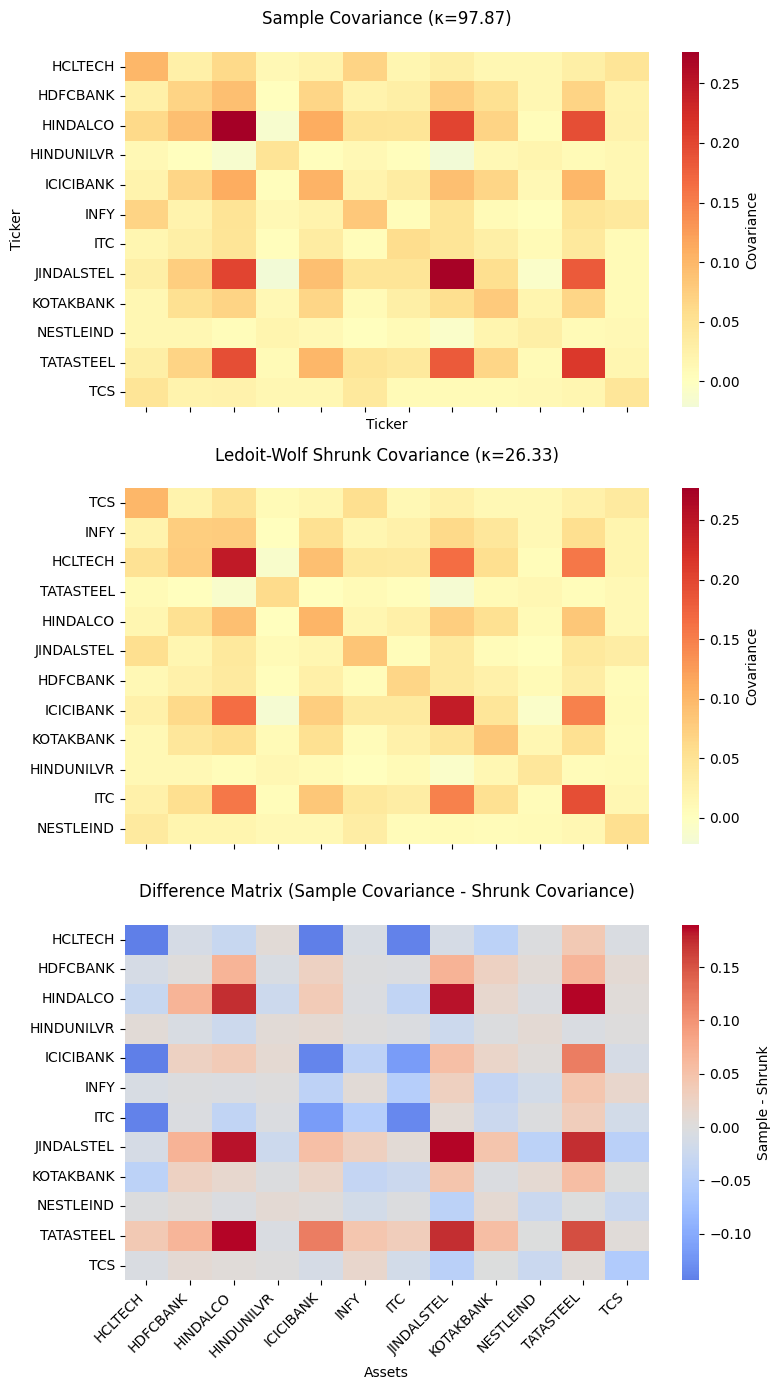

In [43]:

# Clean tickers (remove .NS)
sample_cov.columns = sample_cov.columns.str.replace('.NS', '')
sample_cov.index = sample_cov.index.str.replace('.NS', '')
lw_cov.columns = lw_cov.columns.str.replace('.NS', '')
lw_cov.index = lw_cov.index.str.replace('.NS', '')

# Set common color scale for fair comparison
vmin = min(sample_cov.values.min(), lw_cov.values.min())
vmax = max(sample_cov.values.max(), lw_cov.values.max())

# 3x1 layout: Sample | Shrunk | Difference
fig, axs = plt.subplots(3, 1, figsize=(8, 14), sharex=True)

# 1. Sample Covariance
sns.heatmap(sample_cov, annot=False, cmap='RdYlBu_r', center=0, 
            vmin=vmin, vmax=vmax, ax=axs[0],
            cbar_kws={'label': 'Covariance'})
axs[0].set_title(f'Sample Covariance (κ={kappa_sample:.2f})', fontsize=12, pad=20)
axs[0].set_xticklabels(sample_cov.columns, rotation=45, ha='right')
axs[0].set_yticklabels(sample_cov.index)

# 2. Shrunk Covariance
sns.heatmap(lw_cov, annot=False, cmap='RdYlBu_r', center=0, 
            vmin=vmin, vmax=vmax, ax=axs[1],
            cbar_kws={'label': 'Covariance'})
axs[1].set_title(f'Ledoit-Wolf Shrunk Covariance (κ={kappa_lw:.2f})', fontsize=12, pad=20)
axs[1].set_xticklabels(lw_cov.columns, rotation=45, ha='right')
axs[1].set_yticklabels(lw_cov.index)

# 3. Difference Heatmap (Sample - Shrunk)
diff_cov = sample_cov - lw_cov
sns.heatmap(diff_cov, annot=False, cmap='coolwarm', center=0, ax=axs[2],
            cbar_kws={'label': 'Sample - Shrunk'})
axs[2].set_title('Difference Matrix (Sample Covariance - Shrunk Covariance)', fontsize=12, pad=20)
axs[2].set_xlabel('Assets')
axs[2].set_xticklabels(diff_cov.columns, rotation=45, ha='right')
axs[2].set_yticklabels(diff_cov.index)

plt.tight_layout()
plt.show()


In [34]:
# Print quantitative summary
print("\n" + "="*50)
print("HEATMAP COMPARISON SUMMARY")
print("="*50)
print(f"Color scale: [{vmin:.4f}, {vmax:.4f}]")
print(f"Mean Absolute Difference: {np.abs(diff_cov.values).mean():.4f}")
print(f"Max Absolute Difference:  {np.abs(diff_cov.values).max():.4f}")
print(f"Frobenius norm (Sample):  {np.linalg.norm(sample_cov.values):.2f}")
print(f"Frobenius norm (Shrunk):  {np.linalg.norm(lw_cov.values):.2f}")
print(f"Relative change:          {(np.linalg.norm(sample_cov.values)/np.linalg.norm(lw_cov.values)-1)*100:.1f}%")


HEATMAP COMPARISON SUMMARY
Color scale: [-0.0217, 0.2765]
Mean Absolute Difference: 0.0394
Max Absolute Difference:  0.1895
Frobenius norm (Sample):  0.83
Frobenius norm (Shrunk):  0.71
Relative change:          16.7%


Step 6: Out-of-sample Performance (Test Period)

In [35]:
portfolio_returns_sample = (test_returns @ w_sample).mean() * 12
portfolio_returns_lw = (test_returns @ w_lw).mean() * 12
sharpe_sample = portfolio_returns_sample / (test_returns @ w_sample).std() * 12**0.5
sharpe_lw = portfolio_returns_lw / (test_returns @ w_lw).std() * 12**0.5

print("\nOut-of-Sample Performance (2025):")
print(f"Sample Cov Annual Return: {portfolio_returns_sample:.2%}")
print(f"LW Cov Annual Return:    {portfolio_returns_lw:.2%}")
print(f"Sample Cov Sharpe:       {sharpe_sample:.3f}")
print(f"LW Cov Sharpe:          {sharpe_lw:.3f}")


Out-of-Sample Performance (2025):
Sample Cov Annual Return: 6.75%
LW Cov Annual Return:    10.61%
Sample Cov Sharpe:       3.766
LW Cov Sharpe:          7.194


> Visualization 2: Weight Sensitivity Plot (Banking Crisis period)

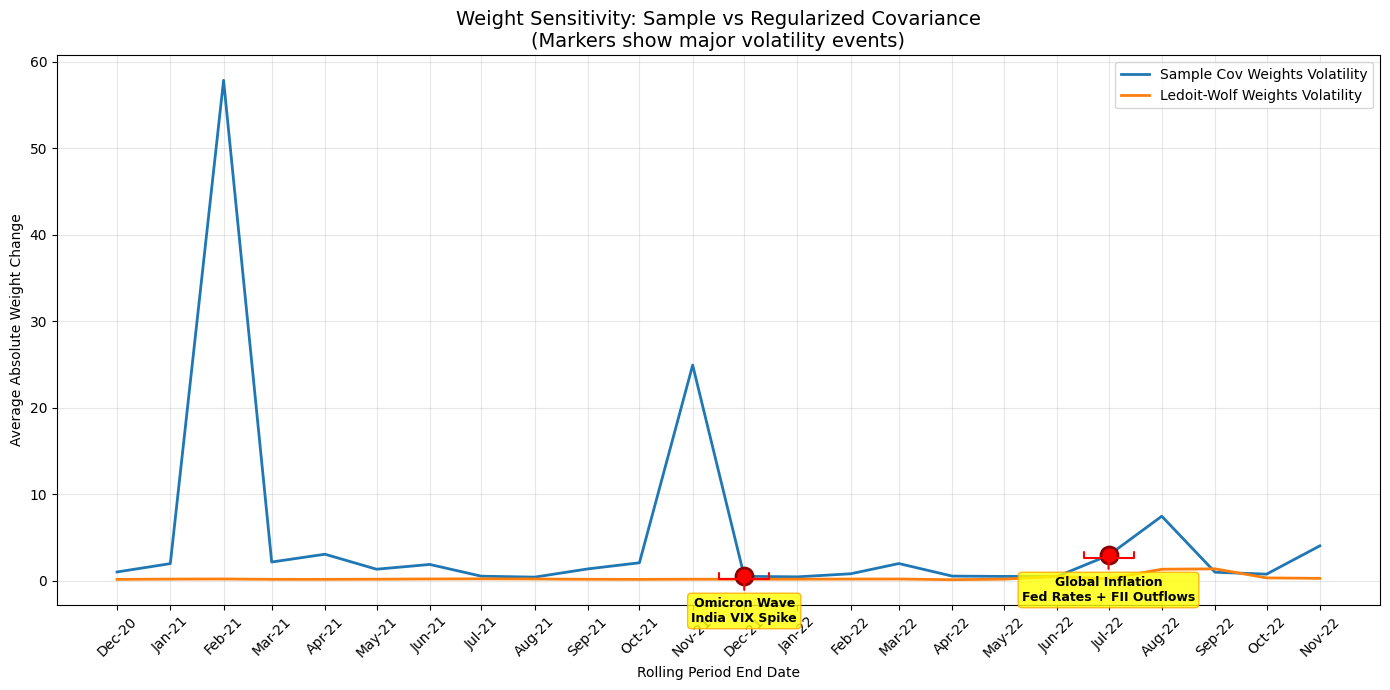

In [42]:
# Find March 2020 (COVID banking stress) weights sensitivity
crisis_start = train_returns.loc['2020-03-01':].index[0] if '2020-03-01' in train_returns.index else train_returns.index[6]
rolling_periods = []
for i in range(12, len(train_returns)-12):
    window_returns = train_returns.iloc[i-12:i]
    window_cov_sample = window_returns.cov() * 12
    window_cov_lw = LedoitWolf().fit(window_returns).covariance_ * 12
    
    w_s = max_sharpe_weights(pd.DataFrame(window_cov_sample, index=tickers, columns=tickers), window_returns.mean()*12)
    w_l = max_sharpe_weights(pd.DataFrame(window_cov_lw, index=tickers, columns=tickers), window_returns.mean()*12)
    
    rolling_periods.append((window_returns.index[-1], np.abs(w_s - w_sample).mean(), np.abs(w_l - w_lw).mean()))

rolling_df = pd.DataFrame(rolling_periods, columns=['Date', 'Sample_Volatility', 'LW_Volatility'])
rolling_df['Date'] = pd.to_datetime(rolling_df['Date'])

date_labels = [d.strftime('%b-%y') for d in rolling_df['Date']]

plt.figure(figsize=(14, 7))
plt.plot(rolling_df['Date'], rolling_df['Sample_Volatility'], label='Sample Cov Weights Volatility', linewidth=2)
plt.plot(rolling_df['Date'], rolling_df['LW_Volatility'], label='Ledoit-Wolf Weights Volatility', linewidth=2)

# Event markers with labels positioned ABOVE the marker
events = {
    '2022-06-17': 'Global Inflation\nFed Rates + FII Outflows',
    '2021-12-01': 'Omicron Wave\nIndia VIX Spike'
}

for date_str, label in events.items():
    event_date = pd.to_datetime(date_str)
    # Find closest index in rolling_df
    closest_idx = (rolling_df['Date'] - event_date).abs().idxmin()
    event_x = rolling_df['Date'].iloc[closest_idx]
    event_y = rolling_df['Sample_Volatility'].iloc[closest_idx]
    
    # Add marker (red circle)
    plt.scatter(event_x, event_y, color='red', s=150, zorder=5, marker='o', 
                edgecolors='darkred', linewidth=2)
    
    # Position label VERTICALLY ABOVE marker (negative offset moves UP)
    plt.annotate(label, 
                xy=(event_x, event_y),
                xytext=(0, -35),  # Move 35 points UP from marker
                textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8,
                         edgecolor='orange', linewidth=1),
                arrowprops=dict(arrowstyle='-[,widthB=2,lengthB=0.5', lw=1.5, color='red'),
                fontsize=9, ha='center', va='bottom',  # Center align, bottom of box at position
                fontweight='bold', zorder=10)

plt.title('Weight Sensitivity: Sample vs Regularized Covariance\n(Markers show major volatility events)', fontsize=14)
plt.ylabel('Average Absolute Weight Change')
plt.xlabel('Rolling Period End Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rolling_df['Date'], date_labels, rotation=45)
plt.tight_layout()
plt.show()
